In [49]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import matplotlib.pyplot as plt
import open3d as o3d
import torch

from ppdr.utils.dataset import HypersimDataset
from ppdr.utils.geometry import depth_to_point_cloud, edge_mask
from ppdr.utils.reader import HypersimReader
from ppdr.utils.transform import image_tensor2array


def export_cloud(points, colors, name):
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points)
    pcd.colors = o3d.utility.Vector3dVector(colors)
    o3d.io.write_point_cloud(name, pcd)


In [ ]:
reader = HypersimReader("../data/hypersim_test_set")
dataset = HypersimDataset(reader)

entry_name = "ai_048_010_cam_02_29"
entry = dataset.get_entry_by_name(entry_name)
image = entry["image"]
real_depth = entry["depth"]
valid_mask = entry["valid_mask"]
ndc_to_cam = entry["ndc_to_cam"]

In [52]:
mask = edge_mask(image.unsqueeze(0), canny_low=0.01, canny_high=0.1, dilation_px=4)


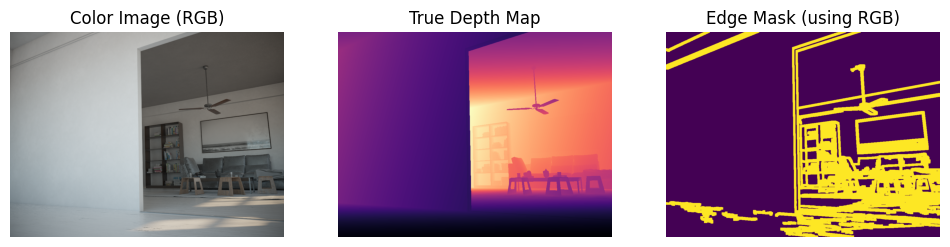

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 6))

axes[0].imshow(image_tensor2array(image))
axes[0].set_title("Color Image (RGB)")
axes[0].axis("off")

axes[1].imshow(real_depth.numpy(), "magma")
axes[1].set_title("True Depth Map")
axes[1].axis("off")

axes[2].imshow(mask.squeeze().numpy())
axes[2].set_title("Edge Mask (using RGB)")
axes[2].axis("off")

plt.show()

In [54]:
colors = image_tensor2array(image)[valid_mask.numpy()]
real_points = depth_to_point_cloud(real_depth, ndc_to_cam, valid_mask).numpy()

In [ ]:
from ppdr.models import PPD
from ppdr.utils.geometry import recover_metric_depth_from_log

ppd = PPD(
    semantics_path="../checkpoints/depth_anything_v2_vitl.pth",
    model_path="../checkpoints/ppd.pth",
)

ppd_depth = (
    ppd.predict(image.to(ppd.device).unsqueeze(0))[0].squeeze(0).to(device="cpu")
)
torch.save(ppd_depth, f"precomputed/{entry_name}_ppd_depth.pt")


In [ ]:
from ppdr.models import DAv2Cleaned
from ppdr.utils.geometry import recover_metric_depth_from_disparity

dav2 = DAv2Cleaned(model_path="../checkpoints/depth_anything_v2_vitl.pth")

dav2_disp, mask = dav2.predict(image.to(dav2.device).unsqueeze(0))
dav2_disp.squeeze(0).to(device="cpu")
mask.squeeze(0).to(device="cpu")

torch.save(dav2_disp, f"precomputed/{entry_name}_dav2_disp.pt")


In [ ]:
from ppdr.utils.heuristic import clean_flying_pixels

ppd_depth = torch.load("ppd_depth.pt")
dav2_disp = torch.load("dav2_disp.pt")

ppd_depth = recover_metric_depth_from_log(ppd_depth, real_depth, valid_mask)
dav2_depth = recover_metric_depth_from_disparity(dav2_disp, real_depth, valid_mask)
dav2cleaned_depth = clean_flying_pixels(dav2_depth, image)

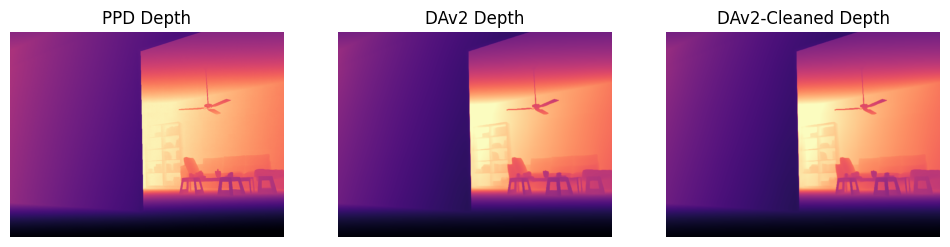

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 6))

axes[0].imshow(ppd_depth.numpy(), "magma")
axes[0].set_title("PPD Depth")
axes[0].axis("off")

axes[1].imshow(dav2_depth.numpy(), "magma")
axes[1].set_title("DAv2 Depth")
axes[1].axis("off")

axes[2].imshow(dav2cleaned_depth.numpy(), "magma")
axes[2].set_title("DAv2-Cleaned Depth")
axes[2].axis("off")

fig.show()

In [59]:
ppd_points = depth_to_point_cloud(ppd_depth, ndc_to_cam, valid_mask).numpy()
export_cloud(ppd_points, colors, "ppd_cloud.ply")

In [60]:
export_cloud(real_points, colors, "real_cloud.ply")

In [61]:
dav2_points = depth_to_point_cloud(dav2_depth, ndc_to_cam, valid_mask).numpy()
export_cloud(dav2_points, colors, "dav2_cloud.ply")

In [62]:
dav2cleaned_points = depth_to_point_cloud(
    dav2cleaned_depth, ndc_to_cam, valid_mask
).numpy()
export_cloud(dav2cleaned_points, colors, "dav2cleaned_cloud.ply")